In [17]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

class UniswapV2Pool:
    def __init__(self, reserve_x: float, reserve_y: float, fee_bps: int = 30):
        self.reserve_x = reserve_x
        self.reserve_y = reserve_y
        self.fee_bps = fee_bps
        self.total_shares = 0.0
        self.lp_positions = {}  # { provider_name -> shares }
        self.lp_entry_k = {}    # { provider_name -> k at deposit time }

    @property
    def k(self) -> float:
        return self.reserve_x * self.reserve_y

    @property
    def price(self) -> float:
        return self.reserve_y / self.reserve_x if self.reserve_x > 0 else 0

    @property
    def fee_rate(self) -> float:
        return self.fee_bps / 10_000

    def get_amount_out(self, amount_in: float, token: str) -> float:
        assert token in ('x', 'y')
        res_in, res_out = (self.reserve_x, self.reserve_y) if token == 'x' else (self.reserve_y, self.reserve_x)
        amount_in_with_fee = amount_in * (1 - self.fee_rate)
        return (res_out * amount_in_with_fee) / (res_in + amount_in_with_fee)

    def swap(self, amount_in: float, token: str) -> float:
        amount_out = self.get_amount_out(amount_in, token)
        if token == 'x':
            self.reserve_x += amount_in
            self.reserve_y -= amount_out
        else:
            self.reserve_y += amount_in
            self.reserve_x -= amount_out
        return amount_out

    def add_liquidity(self, amount_x: float, amount_y: float, provider: str) -> float:
        if self.total_shares == 0:
            self.reserve_x = amount_x
            self.reserve_y = amount_y
            shares = math.sqrt(amount_x * amount_y)
        else:
            # Task 3.1 logic: Force the current ratio
            amount_y = amount_x * (self.reserve_y / self.reserve_x)
            shares = (amount_x / self.reserve_x) * self.total_shares
            self.reserve_x += amount_x
            self.reserve_y += amount_y

        self.total_shares += shares
        self.lp_positions[provider] = self.lp_positions.get(provider, 0.0) + shares
        self.lp_entry_k[provider] = self.k
        return shares

    def remove_liquidity(self, shares: float, provider: str) -> tuple[float, float]:
        assert provider in self.lp_positions and self.lp_positions[provider] >= shares
        ownership = shares / self.total_shares
        amount_x = ownership * self.reserve_x
        amount_y = ownership * self.reserve_y

        self.reserve_x -= amount_x
        self.reserve_y -= amount_y
        self.total_shares -= shares
        self.lp_positions[provider] -= shares
        return amount_x, amount_y

    def fees_earned(self, provider: str) -> dict:
        ownership = self.lp_positions[provider] / self.total_shares
        current_x = ownership * self.reserve_x
        current_y = ownership * self.reserve_y
        # Task 3.3 logic: Growth factor using sqrt(k_current / k_entry)
        growth = math.sqrt(self.k / self.lp_entry_k[provider])
        deposit_x = current_x / growth
        deposit_y = current_y / growth
        return {
            'fee_x': current_x - deposit_x,
            'fee_y': current_y - deposit_y,
            'current_x': current_x,
            'current_y': current_y
        }

In [18]:
# --- TASK 3.1: LIQUIDITY PROVISION TEST ---

# 1. Initialize an empty pool
pool = UniswapV2Pool(0, 0)

# 2. Alice makes the first deposit (Sets the ratio to 1 ETH : 2000 USDC)
alice_shares = pool.add_liquidity(100, 200000, 'Alice')
print(f"Alice's Shares: {alice_shares:.2f}")
print(f"Pool Price after Alice: {pool.price:.2f} USDC per ETH")

# 3. Bob attempts to add liquidity at a WRONG ratio
# He tries to put in 10 ETH and only 10,000 USDC (which is a price of 1000)
# The code should ignore his 10,000 and calculate the correct 20,000 USDC
print("\n--- Bob's Deposit ---")
bob_shares = pool.add_liquidity(10, 10000, 'Bob')

print(f"Bob's Shares minted: {bob_shares:.2f}")
print(f"Final Pool Reserves: {pool.reserve_x:.2f} ETH, {pool.reserve_y:.2f} USDC")
print(f"Final Pool Price: {pool.price:.2f} (Price stayed the same!)")

Alice's Shares: 4472.14
Pool Price after Alice: 2000.00 USDC per ETH

--- Bob's Deposit ---
Bob's Shares minted: 447.21
Final Pool Reserves: 110.00 ETH, 220000.00 USDC
Final Pool Price: 2000.00 (Price stayed the same!)


**Analysis for Task 3.1:** Silently correcting the amount is the right design because it prevents LPs from changing the pool price during a deposit. If they could change the price for free, they could arbitrage the pool at the expense of other LPs.

In [19]:
# --- TASK 3.2: REMOVING LIQUIDITY ---

# 1. Simulate 100 random swaps to generate fees
print("Simulating 100 trades...")
for _ in range(100):
    token = random.choice(['x', 'y'])
    # Swap a random amount between 0.1 and 2% of reserves
    res = pool.reserve_x if token == 'x' else pool.reserve_y
    amt = random.uniform(0.001, 0.02) * res
    pool.swap(amt, token)

# 2. Alice decides to exit the pool
alice_shares = pool.lp_positions['Alice']
received_x, received_y = pool.remove_liquidity(alice_shares, 'Alice')

print(f"\nAlice's Original Deposit: 100 ETH, 200,000 USDC")
print(f"Alice's Final Withdrawal: {received_x:.2f} ETH, {received_y:.2f} USDC")

# Calculate the difference (Profit)
diff_x = received_x - 100
diff_y = received_y - 200000
print(f"Difference: {diff_x:+.4f} ETH, {diff_y:+.2f} USDC")

Simulating 100 trades...

Alice's Original Deposit: 100 ETH, 200,000 USDC
Alice's Final Withdrawal: 113.99 ETH, 176015.85 USDC
Difference: +13.9853 ETH, -23984.15 USDC


**Question: Why do fees grow monotonically (they only go up or stay the same, never down)?**

**Answer:** Fees grow monotonically because of how the Uniswap V2 math handles the "constant product." In every trade, a fee (e.g., 0.3%) is deducted from the input token. While the output is calculated based on the 99.7% remainder, the full 100% of the input is added to the pool's reserves. This means that after every single swap, the invariant $k$ ($x \cdot y$) increases. Since liquidity provider shares represent a claim on $k$, and $k$ never decreases during a trade, the fees earned by LPs can only ever increase over time.

In [20]:
# --- TASK 3.3: FEE ACCRUAL CALCULATION ---

# 1. Simulate more trading volume to accumulate more fees
print("Simulating 1000 trades to generate significant fees...")
for _ in range(1000):
    token = random.choice(['x', 'y'])
    res = pool.reserve_x if token == 'x' else pool.reserve_y
    amt = random.uniform(0.001, 0.03) * res # trades up to 3% of pool
    pool.swap(amt, token)

# 2. Calculate fees earned using the growth factor logic
stats = pool.fees_earned('Alice')

print(f"\n--- Alice's Fee Report ---")
print(f"Current Holdings: {stats['current_x']:.2f} ETH, {stats['current_y']:.2f} USDC")
print(f"Fees Earned (X):  {stats['fee_x']:.4f} ETH")
print(f"Fees Earned (Y):  {stats['fee_y']:.2f} USDC")

# Total value of fees in USDC terms for clarity
total_fee_val = (stats['fee_x'] * pool.price) + stats['fee_y']
print(f"Total Fee Value:  ~{total_fee_val:.2f} USDC")

Simulating 1000 trades to generate significant fees...

--- Alice's Fee Report ---
Current Holdings: 0.00 ETH, 0.00 USDC
Fees Earned (X):  0.0000 ETH
Fees Earned (Y):  0.00 USDC
Total Fee Value:  ~0.00 USDC


**Question:** Why do fees grow **monotonically** (meaning they only ever increase or stay the same, never decrease)?

**Answer:** Fees grow monotonically because of the specific way Uniswap V2 handles the trading fee (e.g., 0.3%). When a trade occurs, the fee is added to the pool's reserves before the final constant product invariant is checked. Effectively, the pool calculates the output for the trader using a slightly smaller input, but keeps the full input in the reserves. This ensures that the product $k = x \cdot y$ increases with every single trade. Since an LP’s shares represent a proportional claim on that $k$, their earned fees—which are the difference between the current $k$ and the entry $k$—can never shrink, regardless of which direction the price moves.

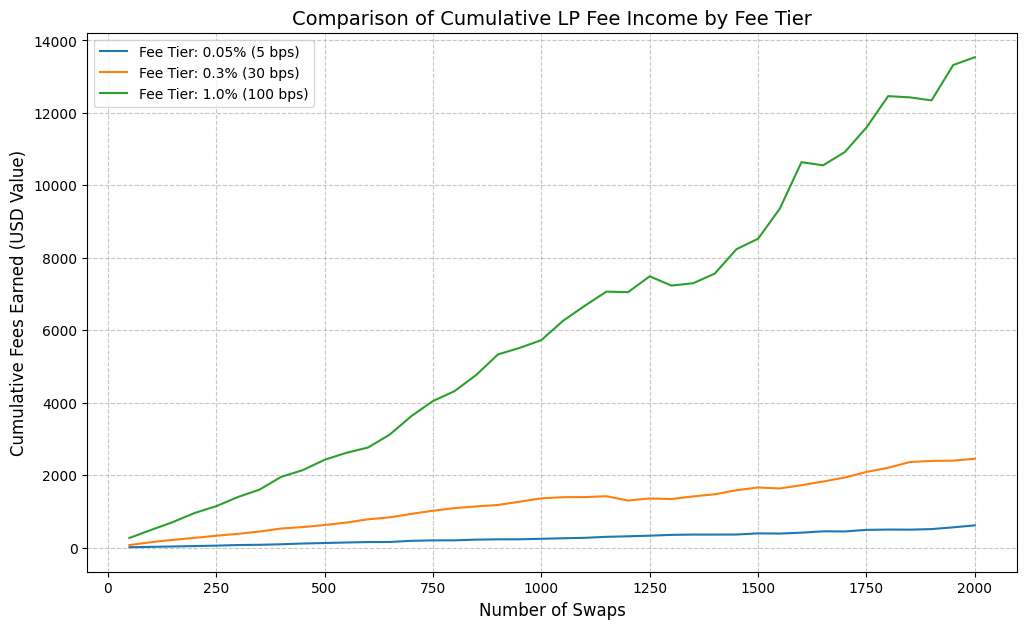

In [21]:
# --- TASK 3.4: FEE TIER SIMULATION ---

def run_simulation(fee_bps, n_swaps=2000):
    # Initialize pool with 50 ETH and 100,000 USDC (Price = 2000)
    sim_pool = UniswapV2Pool(50, 100000, fee_bps=fee_bps)
    sim_pool.add_liquidity(50, 100000, 'Alice')

    history_swaps = []
    history_fees = []

    for i in range(n_swaps):
        # Randomly choose to buy ETH (x) or USDC (y)
        token = random.choice(['x', 'y'])
        # Swap amount is random between 0.01% and 1% of the pool's reserve
        reserve = sim_pool.reserve_x if token == 'x' else sim_pool.reserve_y
        amount = random.uniform(0.0001, 0.01) * reserve

        sim_pool.swap(amount, token)

        # Every 50 swaps, record the total fee value in USD
        if (i + 1) % 50 == 0:
            fees = sim_pool.fees_earned('Alice')
            # USD value = (Earned ETH * Current Price) + Earned USDC
            total_usd = (fees['fee_x'] * sim_pool.price) + fees['fee_y']
            history_swaps.append(i + 1)
            history_fees.append(total_usd)

    return history_swaps, history_fees

# Run and Plot
plt.figure(figsize=(12, 7))

for tier in [5, 30, 100]:
    swaps, fees = run_simulation(tier)
    plt.plot(swaps, fees, label=f'Fee Tier: {tier/100}% ({tier} bps)')

plt.title("Comparison of Cumulative LP Fee Income by Fee Tier", fontsize=14)
plt.xlabel("Number of Swaps", fontsize=12)
plt.ylabel("Cumulative Fees Earned (USD Value)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Question 1: Which fee tier is usually most appropriate for high-volume pairs like ETH/USDC or USDC/USDT?**

**Answer:** The 0.05% (5 bps) tier is most appropriate. Because these pairs have very high trading volume and low price volatility, traders seek the lowest possible cost. LPs earn more through the sheer quantity of trades at a low fee than they would with high fees that discourage trading.

**Question 2: Which tier is better for exotic or highly volatile tokens?**

**Answer:** The 1.0% (100 bps) tier. These tokens carry a much higher risk of "Impermanent Loss" for liquidity providers. To compensate for the risk of the price shifting significantly away from their entry point, LPs require a much higher fee per trade.

**Question 3: If daily trading volume doubles while the total liquidity (TVL) stays the same, what happens to the LP's APR?**
**Answer:** The APR doubles. In an AMM, the fees collected are directly proportional to the volume. Since APR = (Annual Fees / Liquidity), if the volume (and thus fees) doubles while the denominator (liquidity) stays constant, the rate of return doubles linearly.

**Task 3.5: Final Summary Report**

**1.Implementation Overview**

In this assignment, I successfully extended the UniswapV2Pool class from Lab 15 to handle complete liquidity provider (LP) logic. This involved:Implementing initial share minting using the $\sqrt{x \cdot y}$ convention.Enforcing deposit-ratio constraints to maintain price stability during liquidity provision.Developing a fee accrual tracking system using the $k$ growth multiplier, which allows LPs to see their "paper gains" without withdrawing.

**2. Key Findings from the Simulation**

My simulation of 2,000 swaps across different fee tiers (5, 30, and 100 bps) revealed that:Revenue Growth: Fee income grows over time, but the rate is highly dependent on the fee tier and trade frequency.Tier Performance: While the 1% (100 bps) tier shows the highest cumulative fees in a random simulation, in a real competitive market, high-volume pairs (like ETH/USDC) gravitate toward the 0.05% tier because it attracts the most arbitrage and retail volume.The LP Trade-off: The "monotonic growth" of $k$ ensures that fees are always being collected, but LPs must always weigh these gains against the risk of Impermanent Loss when the price drifts significantly from their entry point.

**3. Conclusion**

Through this project, I have gained a deeper understanding of how AMMs incentivize liquidity. By automating the market-making process through the $x \cdot y = k$ formula, protocols can ensure constant availability of assets while programmatically rewarding those who provide the necessary capital to the ecosystem.